# DeepLense Specific Task VII — Residual-Potential PINN on top of DenseNet161

This notebook starts from your strong **Common Task I DenseNet161** pipeline and upgrades it into a **Task VII-compliant physics-guided model**.

## Main upgrades over the plain DenseNet notebook

- keep the strong **3-channel DenseNet input**:
  - `raw/asinh`
  - LensPINN-style edge channel
  - Gaussian residual channel
- predict a **smooth elliptical lens + external shear**
- predict a small **residual lensing potential** `δψ(θ)` and convert it to extra deflection with differentiable finite differences
- enforce the **thin-lens equation** inside the forward pass:
  - `β = θ - α(θ)`
- replace the coarse source image with a **continuous source field** (coordinate MLP)
- train with **low-pass smooth-lens reconstruction** instead of full-image reconstruction
- classify with **residual + Jacobian-derived physics maps**:
  - `raw`
  - `rendered`
  - `residual`
  - `|residual|`
  - `∇residual`
  - `detA`
  - `log μ`

This is intentionally a **higher-upside PINN** than the earlier SIS-style side branch. It is still rooted in your DenseNet notebook, but the physics branch now has enough structure to matter.

Run it as a separate **Task VII notebook**, and compare against your frozen Common Task I baseline using the same split, D4 TTA, and top-k checkpoint ensemble.


In [1]:
# P100-safe: do NOT upgrade torch / torchvision / torchaudio here
import sys
import subprocess

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "timm", "scikit-learn", "scipy"],
    check=False,
)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'timm', 'scikit-learn', 'scipy'], returncode=0)

In [2]:

import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("capability:", torch.cuda.get_device_capability(0))


torch: 2.9.0+cu126
torchvision: 0.24.0+cu126
cuda available: True
gpu: Tesla P100-PCIE-16GB
capability: (6, 0)


In [3]:

import os
import gc
import json
import math
import copy
import heapq
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

import timm
from timm.loss import LabelSmoothingCrossEntropy
from timm.utils import ModelEmaV2

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)


In [4]:

@dataclass
class CFG:
    # paths
    data_root: str | None = None
    output_dir: str = "./outputs_task7_residual_pinn_densenet"
    split_csv_dir: str = "./outputs_task7_residual_pinn_densenet/splits"
    ckpt_dir: str = "./outputs_task7_residual_pinn_densenet/checkpoints"

    # classes
    class_names: tuple = ("no", "sphere", "vort")

    # DenseNet backbone
    model_name: str = "densenet161"
    pretrained: bool = True
    in_chans: int = 3
    drop_rate: float = 0.0

    # image
    img_size: int = 150
    normalize_to_minus1_1: bool = True

    # optimization
    epochs: int = 36
    warmup_epochs: int = 3
    batch_size: int = 16
    num_workers: int = 4
    lr: float = 2.0e-4
    min_lr: float = 1e-6
    weight_decay: float = 1e-4
    label_smoothing: float = 0.02
    grad_clip: float = 1.0
    use_amp: bool = True

    # training regularization
    use_ema: bool = True
    ema_decay: float = 0.9995
    early_stopping_patience: int = 8
    save_top_k: int = 3

    # augmentation on the base grayscale image
    use_d4_train_aug: bool = True
    use_translation_aug: bool = True
    max_shift_px: int = 6
    use_psf_aug: bool = True
    psf_prob: float = 0.40
    psf_sigma_range: tuple = (0.3, 1.2)
    use_noise_aug: bool = True
    noise_prob: float = 0.40
    noise_std_range: tuple = (0.003, 0.025)

    # baseline physics channels
    use_asinh_raw: bool = True
    asinh_soften: float = 0.15
    residual_sigma: float = 2.0
    edge_eps: float = 1e-6

    # residual-potential PINN branch
    physics_feat_dim: int = 192
    physics_branch_init_logit: float = -2.0  # sigmoid ~= 0.12
    lens_theta_min: float = 0.05
    lens_theta_max: float = 1.00
    lens_center_max: float = 0.20
    axis_ratio_min: float = 0.45
    axis_ratio_max: float = 1.00
    lens_shear_max: float = 0.12
    delta_psi_max: float = 0.04
    renderer_eps: float = 1e-4

    # coordinate source field
    source_latent_dim: int = 32
    source_hidden_dim: int = 64
    source_num_layers: int = 3
    source_num_bands: int = 4
    source_max_freq: float = 8.0
    source_chunk_size: int = 4096

    # loss weights
    base_aux_ce_weight: float = 0.20
    physics_aux_ce_weight: float = 0.08
    lowpass_recon_weight: float = 0.12
    recon_ramp_epochs: int = 6
    delta_psi_lap_weight: float = 0.010
    delta_psi_grad_weight: float = 0.002
    delta_psi_amp_weight: float = 0.002
    lens_center_reg_weight: float = 0.001
    lens_shear_reg_weight: float = 0.001
    axis_ratio_reg_weight: float = 0.0005

    # evaluation
    use_d4_tta: bool = True
    final_eval_top_k: int = 3

    # reproducibility
    seed: int = 42

cfg = CFG()
for p in [cfg.output_dir, cfg.split_csv_dir, cfg.ckpt_dir]:
    Path(p).mkdir(parents=True, exist_ok=True)
cfg


CFG(data_root=None, output_dir='./outputs_task7_residual_pinn_densenet', split_csv_dir='./outputs_task7_residual_pinn_densenet/splits', ckpt_dir='./outputs_task7_residual_pinn_densenet/checkpoints', class_names=('no', 'sphere', 'vort'), model_name='densenet161', pretrained=True, in_chans=3, drop_rate=0.0, img_size=150, normalize_to_minus1_1=True, epochs=36, warmup_epochs=3, batch_size=16, num_workers=4, lr=0.0002, min_lr=1e-06, weight_decay=0.0001, label_smoothing=0.02, grad_clip=1.0, use_amp=True, use_ema=True, ema_decay=0.9995, early_stopping_patience=8, save_top_k=3, use_d4_train_aug=True, use_translation_aug=True, max_shift_px=6, use_psf_aug=True, psf_prob=0.4, psf_sigma_range=(0.3, 1.2), use_noise_aug=True, noise_prob=0.4, noise_std_range=(0.003, 0.025), use_asinh_raw=True, asinh_soften=0.15, residual_sigma=2.0, edge_eps=1e-06, physics_feat_dim=192, physics_branch_init_logit=-2.0, lens_theta_min=0.05, lens_theta_max=1.0, lens_center_max=0.2, axis_ratio_min=0.45, axis_ratio_max=1.0

In [5]:

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [6]:

def find_dataset_root(explicit_root: str | None = None) -> Path:
    candidates = []
    if explicit_root is not None:
        candidates.append(Path(explicit_root))

    candidates += [
        Path("/kaggle/input/datasets/ashaeyx/common-task-dataset/dataset"),
        Path("/kaggle/input/datasets/adityaaru/dataset-vii/dataset"),
        Path("/kaggle/input"),
        Path("/content/dataset"),
        Path("./dataset"),
        Path("."),
    ]

    def is_valid_root(p: Path) -> bool:
        return (p / "train").exists() and (p / "val").exists()

    for c in candidates:
        if is_valid_root(c):
            return c
        for sub in c.glob("**/*"):
            if sub.is_dir() and is_valid_root(sub):
                return sub

    raise FileNotFoundError(
        "Could not find dataset root containing train/ and val/ folders. "
        "Set CFG.data_root manually if needed."
    )


def list_image_files(folder: Path):
    exts = {".npy", ".npz", ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])


def build_full_dataframe(train_dir: Path, val_dir: Path, class_names: tuple[str, ...]) -> pd.DataFrame:
    rows = []
    for split_name, split_dir in [("provided_train", train_dir), ("provided_val", val_dir)]:
        for label, cls in enumerate(class_names):
            cls_dir = split_dir / cls
            files = list_image_files(cls_dir)
            rows.extend([
                {
                    "path": str(fp),
                    "label": label,
                    "class_name": cls,
                    "source_split": split_name,
                }
                for fp in files
            ])
    return pd.DataFrame(rows)


dataset_root = find_dataset_root(cfg.data_root)
train_dir = dataset_root / "train"
val_dir = dataset_root / "val"
print("Dataset root:", dataset_root)

full_df = build_full_dataframe(train_dir, val_dir, cfg.class_names)
print("Full dataset size:", len(full_df))
display(full_df.head())


Dataset root: /kaggle/input/datasets/adityaaru/dataset-vii/dataset
Full dataset size: 37500


,path,label,class_name,source_split
0,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train
1,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train
2,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train
3,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train
4,/kaggle/input/datasets/adityaaru/dataset-vii/d...,0,no,provided_train


In [7]:

train_df, val_df = train_test_split(
    full_df,
    test_size=0.10,
    random_state=cfg.seed,
    stratify=full_df["label"],
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

train_df.to_csv(Path(cfg.split_csv_dir) / "train_split.csv", index=False)
val_df.to_csv(Path(cfg.split_csv_dir) / "val_split.csv", index=False)

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print("\nTrain class counts:")
display(train_df.groupby("class_name").size())
print("\nVal class counts:")
display(val_df.groupby("class_name").size())


Train size: 33750
Val size  : 3750

Train class counts:


class_name
no        11250
sphere    11250
vort      11250
dtype: int64


Val class counts:


class_name
no        1250
sphere    1250
vort      1250
dtype: int64

## Preprocessing and physics summary

This notebook keeps your original strong **DenseNet161 3-channel preprocessing** and adds a stronger **physics-guided residual-potential branch**.

**DenseNet branch input**
1. `raw/asinh` channel  
2. LensPINN-style log-contrast + mixed-derivative edge channel  
3. Gaussian residual channel  

**PINN branch**
- raw normalized image (`1 x 150 x 150`)
- smooth lens parameters:
  - `theta_E`
  - `(cx, cy)`
  - axis ratio `q`
  - orientation `phi`
  - external shear `(gamma1, gamma2)`
- small residual potential map `δψ(θ)`
- continuous source field decoded from image features
- differentiable rendering via the lens equation
- residual anomaly maps plus Jacobian-derived features for classification

**Key modeling choice**
- the renderer is asked to explain the **smooth** component of the lens
- the classifier then focuses on what remains in the **residual**, which is where substructure information should live


In [8]:
MIXED_DERIV_KERNEL = np.array(
    [
        [1.0,  0.0, -1.0],
        [0.0,  0.0,  0.0],
        [-1.0, 0.0,  1.0],
    ],
    dtype=np.float32,
) / 4.0


def load_grayscale(path: str) -> np.ndarray:
    p = Path(path)
    ext = p.suffix.lower()

    if ext in {".npy", ".npz"}:
        arr = np.load(p)
        if isinstance(arr, np.lib.npyio.NpzFile):
            key = list(arr.keys())[0]
            arr = arr[key]
    else:
        arr = np.array(Image.open(p).convert("F"), dtype=np.float32)

    arr = np.asarray(arr, dtype=np.float32)

    if arr.ndim == 3:
        if arr.shape[0] == 1:
            arr = arr[0]
        elif arr.shape[-1] == 1:
            arr = arr[..., 0]
        else:
            arr = arr.mean(axis=-1)

    if arr.shape != (cfg.img_size, cfg.img_size):
        arr = np.array(
            Image.fromarray(arr).resize((cfg.img_size, cfg.img_size), resample=Image.BILINEAR),
            dtype=np.float32,
        )

    if not np.isfinite(arr).all():
        arr = np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=0.0).astype(np.float32)

    return arr.astype(np.float32)


def robust_scale01(x: np.ndarray, low_q: float = 1.0, high_q: float = 99.0, eps: float = 1e-6) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [low_q, high_q])
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo + eps)
    return x.astype(np.float32)


def prepare_raw01_for_physics(img: np.ndarray) -> np.ndarray:
    img = np.asarray(img, dtype=np.float32)
    if not np.isfinite(img).all():
        img = np.nan_to_num(img, nan=0.0, posinf=1.0, neginf=0.0).astype(np.float32)

    x_min = float(img.min())
    x_max = float(img.max())

    # The dataset is described as min-max normalised.
    # If augmentation pushes values slightly outside [0, 1], clip them.
    # If values are far outside that range, fall back to a robust [0, 1] scaling.
    if x_min >= -0.10 and x_max <= 1.10:
        raw01 = np.clip(img, 0.0, 1.0)
    else:
        raw01 = robust_scale01(img)

    return raw01.astype(np.float32)


def asinh_stretch01(x01: np.ndarray, soften: float = 0.15, eps: float = 1e-6) -> np.ndarray:
    x01 = np.clip(x01.astype(np.float32), 0.0, 1.0)
    denom = np.arcsinh(1.0 / max(soften, eps))
    out = np.arcsinh(x01 / max(soften, eps)) / max(denom, eps)
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def signed_tanh_to_01(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    x = x.astype(np.float32)
    x = x - np.median(x)
    scale = np.percentile(np.abs(x), 95) + eps
    x = np.tanh(x / scale)
    x = (x + 1.0) / 2.0
    return np.clip(x, 0.0, 1.0).astype(np.float32)


def lenspinn_edge_channel(raw01: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    contrast = raw01.max() / np.clip(raw01, eps, None)
    log_contrast = np.log(contrast + eps)
    amplified = log_contrast ** 2
    mixed = convolve2d(amplified, MIXED_DERIV_KERNEL, mode="same", boundary="symm")
    return signed_tanh_to_01(mixed, eps=eps)


def residual_channel(raw01: np.ndarray, sigma: float = 2.0, eps: float = 1e-6) -> np.ndarray:
    smooth = gaussian_filter(raw01, sigma=sigma)
    resid = raw01 - smooth
    return signed_tanh_to_01(resid, eps=eps)


def translate_reflect(img: np.ndarray, max_shift_px: int) -> np.ndarray:
    if max_shift_px <= 0:
        return img
    h, w = img.shape
    pad = max_shift_px
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode="reflect")
    dy = np.random.randint(-max_shift_px, max_shift_px + 1)
    dx = np.random.randint(-max_shift_px, max_shift_px + 1)
    y0 = pad + dy
    x0 = pad + dx
    return padded[y0:y0+h, x0:x0+w]


def random_d4(img: np.ndarray) -> np.ndarray:
    k = np.random.randint(0, 4)
    out = np.rot90(img, k)
    if np.random.rand() < 0.5:
        out = np.fliplr(out)
    return np.ascontiguousarray(out)


def physics_augment_base(img: np.ndarray) -> np.ndarray:
    img = img.astype(np.float32)

    if cfg.use_d4_train_aug:
        img = random_d4(img)

    if cfg.use_translation_aug:
        img = translate_reflect(img, cfg.max_shift_px)

    if cfg.use_psf_aug and np.random.rand() < cfg.psf_prob:
        sigma = np.random.uniform(*cfg.psf_sigma_range)
        img = gaussian_filter(img, sigma=sigma)

    if cfg.use_noise_aug and np.random.rand() < cfg.noise_prob:
        noise_std = np.random.uniform(*cfg.noise_std_range)
        img = img + np.random.normal(0.0, noise_std, img.shape).astype(np.float32)

    return img.astype(np.float32)


def make_physics_stack_from_raw01(raw01: np.ndarray) -> np.ndarray:
    dense_raw01 = robust_scale01(raw01)
    dense_raw01 = asinh_stretch01(dense_raw01, soften=cfg.asinh_soften) if cfg.use_asinh_raw else dense_raw01
    edge01 = lenspinn_edge_channel(dense_raw01, eps=cfg.edge_eps)
    resid01 = residual_channel(dense_raw01, sigma=cfg.residual_sigma, eps=cfg.edge_eps)
    stacked = np.stack([dense_raw01, edge01, resid01], axis=0).astype(np.float32)

    if cfg.normalize_to_minus1_1:
        stacked = (stacked - 0.5) / 0.5

    return stacked.astype(np.float32)


def make_dual_inputs(img: np.ndarray):
    raw01 = prepare_raw01_for_physics(img)
    dense_stack = make_physics_stack_from_raw01(raw01)
    raw01 = raw01[None, ...].astype(np.float32)
    return dense_stack.astype(np.float32), raw01.astype(np.float32)


In [9]:
class LensPhysicsDataset(Dataset):
    def __init__(self, df: pd.DataFrame, train: bool):
        self.df = df.reset_index(drop=True).copy()
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_grayscale(row.path)

        if self.train:
            img = physics_augment_base(img)

        x_dense, x_raw = make_dual_inputs(img)
        y = int(row.label)
        return (
            torch.from_numpy(x_dense),
            torch.from_numpy(x_raw),
            torch.tensor(y, dtype=torch.long),
        )


train_ds = LensPhysicsDataset(train_df, train=True)
val_ds = LensPhysicsDataset(val_df, train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=cfg.num_workers > 0,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=cfg.num_workers > 0,
)

print("train batches:", len(train_loader))
print("val batches  :", len(val_loader))


train batches: 2110
val batches  : 235


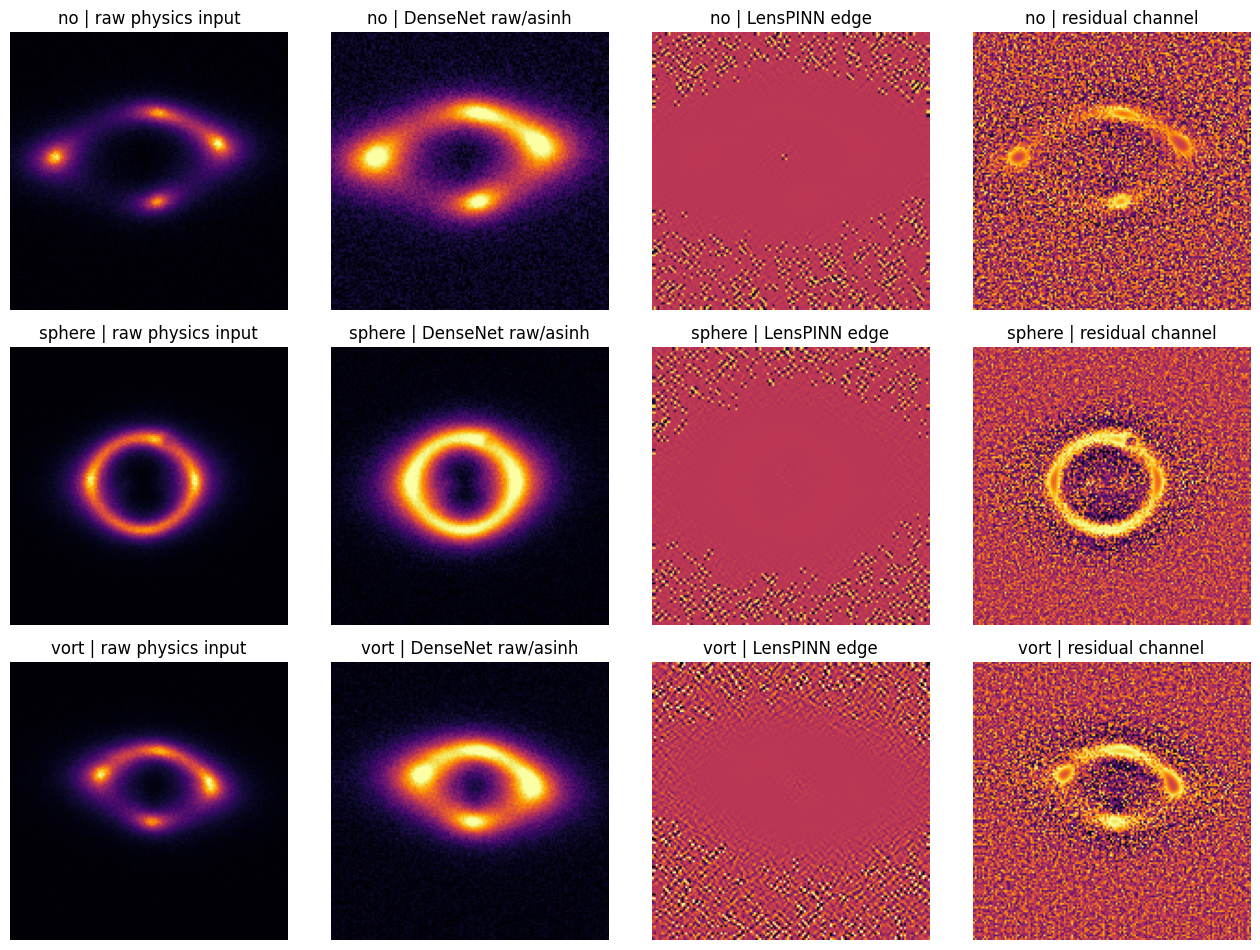

In [10]:
def show_physics_channels(dataset: Dataset, n_per_class: int = 1):
    class_to_indices = defaultdict(list)
    for i, row in dataset.df.iterrows():
        if len(class_to_indices[row.class_name]) < n_per_class:
            class_to_indices[row.class_name].append(i)

    n_rows = len(cfg.class_names)
    fig, axes = plt.subplots(n_rows, 4, figsize=(13, 3.2 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, 0)

    for r, cls in enumerate(cfg.class_names):
        idx = class_to_indices[cls][0]
        x_dense, x_raw, _ = dataset[idx]
        x_dense = x_dense.numpy()
        x_raw = x_raw.numpy()[0]

        if cfg.normalize_to_minus1_1:
            x_dense = (x_dense * 0.5) + 0.5

        panels = [x_raw, x_dense[0], x_dense[1], x_dense[2]]
        titles = [
            f"{cls} | raw physics input",
            f"{cls} | DenseNet raw/asinh",
            f"{cls} | LensPINN edge",
            f"{cls} | residual channel",
        ]

        for c, (panel, title) in enumerate(zip(panels, titles)):
            axes[r, c].imshow(panel, cmap="inferno")
            axes[r, c].set_title(title)
            axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

show_physics_channels(train_ds, n_per_class=1)


In [11]:

class ConvGNAct(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, k: int = 3, s: int = 1, p: int = 1, groups: int = 8):
        super().__init__()
        g = min(groups, out_ch)
        while out_ch % g != 0 and g > 1:
            g -= 1

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, bias=False),
            nn.GroupNorm(g, out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


def conv_reflect(x: torch.Tensor, weight: torch.Tensor) -> torch.Tensor:
    kh, kw = weight.shape[-2:]
    pad_y = kh // 2
    pad_x = kw // 2
    x = F.pad(x, (pad_x, pad_x, pad_y, pad_y), mode="reflect")
    c = x.shape[1]
    return F.conv2d(x, weight.expand(c, 1, kh, kw), groups=c)


class FiniteDifferenceOps(nn.Module):
    def __init__(self, pixel_scale: float, eps: float = 1e-6):
        super().__init__()
        self.pixel_scale = float(pixel_scale)
        self.eps = float(eps)

        dx = torch.tensor([[0.0, 0.0, 0.0], [-0.5, 0.0, 0.5], [0.0, 0.0, 0.0]], dtype=torch.float32) / self.pixel_scale
        dy = torch.tensor([[0.0, -0.5, 0.0], [0.0, 0.0, 0.0], [0.0, 0.5, 0.0]], dtype=torch.float32) / self.pixel_scale
        lap = torch.tensor([[0.0, 1.0, 0.0], [1.0, -4.0, 1.0], [0.0, 1.0, 0.0]], dtype=torch.float32) / (self.pixel_scale ** 2)

        self.register_buffer("dx_kernel", dx[None, None], persistent=False)
        self.register_buffer("dy_kernel", dy[None, None], persistent=False)
        self.register_buffer("lap_kernel", lap[None, None], persistent=False)

    def grad_x(self, x: torch.Tensor) -> torch.Tensor:
        return conv_reflect(x, self.dx_kernel)

    def grad_y(self, x: torch.Tensor) -> torch.Tensor:
        return conv_reflect(x, self.dy_kernel)

    def laplacian(self, x: torch.Tensor) -> torch.Tensor:
        return conv_reflect(x, self.lap_kernel)

    def grad_mag(self, x: torch.Tensor) -> torch.Tensor:
        gx = self.grad_x(x)
        gy = self.grad_y(x)
        return torch.sqrt(gx.square() + gy.square() + self.eps)


class FourierFeatureEncoder(nn.Module):
    def __init__(self, num_bands: int = 4, max_freq: float = 8.0):
        super().__init__()
        self.num_bands = int(num_bands)
        self.max_freq = float(max_freq)
        if self.num_bands > 0:
            freq_bands = torch.logspace(0.0, math.log2(self.max_freq), steps=self.num_bands, base=2.0)
        else:
            freq_bands = torch.empty(0)
        self.register_buffer("freq_bands", freq_bands, persistent=False)

    @property
    def out_dim(self) -> int:
        return 2 + 4 * self.num_bands

    def forward(self, coords: torch.Tensor) -> torch.Tensor:
        feats = [coords]
        if self.num_bands > 0:
            for freq in self.freq_bands:
                scaled = math.pi * coords * freq
                feats.append(torch.sin(scaled))
                feats.append(torch.cos(scaled))
        return torch.cat(feats, dim=-1)


class CoordinateSourceField(nn.Module):
    def __init__(self, latent_dim: int, hidden_dim: int, num_layers: int, num_bands: int, max_freq: float, chunk_size: int):
        super().__init__()
        self.chunk_size = int(chunk_size)
        self.coord_encoder = FourierFeatureEncoder(num_bands=num_bands, max_freq=max_freq)
        in_dim = self.coord_encoder.out_dim + latent_dim

        layers = []
        cur_dim = in_dim
        for _ in range(num_layers):
            layers.extend([
                nn.Linear(cur_dim, hidden_dim),
                nn.GELU(),
            ])
            cur_dim = hidden_dim
        layers.append(nn.Linear(cur_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, beta_grid: torch.Tensor, latent: torch.Tensor) -> torch.Tensor:
        b, h, w, _ = beta_grid.shape
        coords = beta_grid.reshape(b, h * w, 2)
        lat = latent[:, None, :].expand(-1, h * w, -1)

        outputs = []
        for start in range(0, h * w, self.chunk_size):
            end = min(h * w, start + self.chunk_size)
            coords_chunk = coords[:, start:end, :]
            enc_chunk = self.coord_encoder(coords_chunk)
            inp_chunk = torch.cat([enc_chunk, lat[:, start:end, :]], dim=-1)
            out_chunk = self.net(inp_chunk.reshape(-1, inp_chunk.shape[-1]))
            outputs.append(out_chunk.view(b, end - start, 1))

        source = torch.cat(outputs, dim=1).transpose(1, 2).reshape(b, 1, h, w)
        return torch.sigmoid(source)


class PotentialResidualHead(nn.Module):
    def __init__(self, out_scale: float):
        super().__init__()
        self.out_scale = float(out_scale)

        self.enc1 = nn.Sequential(
            ConvGNAct(1, 16, 3, 1, 1, groups=4),
            ConvGNAct(16, 16, 3, 1, 1, groups=4),
        )
        self.down1 = ConvGNAct(16, 24, 3, 2, 1, groups=6)
        self.down2 = ConvGNAct(24, 32, 3, 2, 1, groups=8)

        self.bottleneck = nn.Sequential(
            ConvGNAct(32, 32, 3, 1, 1, groups=8),
            ConvGNAct(32, 32, 3, 1, 1, groups=8),
        )

        # No internal upsampling here.
        self.dec1 = nn.Sequential(
            ConvGNAct(32 + 24, 24, 3, 1, 1, groups=6),
            ConvGNAct(24, 24, 3, 1, 1, groups=6),
        )
        self.dec2 = nn.Sequential(
            ConvGNAct(24 + 16, 16, 3, 1, 1, groups=4),
            ConvGNAct(16, 16, 3, 1, 1, groups=4),
        )

        self.out = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x_raw: torch.Tensor) -> torch.Tensor:
        x1 = self.enc1(x_raw)      # [B,16,H,W]
        x2 = self.down1(x1)        # [B,24,H/2,W/2]
        x3 = self.down2(x2)        # [B,32,H/4,W/4]
        xb = self.bottleneck(x3)

        xu = F.interpolate(xb, size=x2.shape[-2:], mode="bilinear", align_corners=False)
        xu = self.dec1(torch.cat([xu, x2], dim=1))

        xu = F.interpolate(xu, size=x1.shape[-2:], mode="bilinear", align_corners=False)
        xu = self.dec2(torch.cat([xu, x1], dim=1))

        delta_psi = torch.tanh(self.out(xu)) * self.out_scale
        return delta_psi


class ResidualEncoder(nn.Module):
    def __init__(self, in_ch: int, out_dim: int):
        super().__init__()
        self.features = nn.Sequential(
            ConvGNAct(in_ch, 24, 3, 2, 1, groups=6),
            ConvGNAct(24, 48, 3, 2, 1, groups=8),
            ConvGNAct(48, 96, 3, 2, 1, groups=8),
            ConvGNAct(96, 160, 3, 2, 1, groups=8),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(160, out_dim),
            nn.GELU(),
            nn.Dropout(0.10),
        )

    def forward(self, x):
        return self.proj(self.features(x))


class HybridResidualPotentialPINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            cfg.model_name,
            pretrained=cfg.pretrained,
            in_chans=cfg.in_chans,
            num_classes=0,
            global_pool="avg",
            drop_rate=cfg.drop_rate,
        )
        self.backbone_dim = int(getattr(self.backbone, "num_features"))

        self.base_head = nn.Linear(self.backbone_dim, len(cfg.class_names))

        self.param_head = nn.Sequential(
            nn.LayerNorm(self.backbone_dim),
            nn.Linear(self.backbone_dim, 256),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(256, 7),
        )

        self.source_latent_head = nn.Sequential(
            nn.LayerNorm(self.backbone_dim),
            nn.Linear(self.backbone_dim, 192),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(192, cfg.source_latent_dim),
        )

        self.source_field = CoordinateSourceField(
            latent_dim=cfg.source_latent_dim,
            hidden_dim=cfg.source_hidden_dim,
            num_layers=cfg.source_num_layers,
            num_bands=cfg.source_num_bands,
            max_freq=cfg.source_max_freq,
            chunk_size=cfg.source_chunk_size,
        )

        self.delta_psi_head = PotentialResidualHead(out_scale=cfg.delta_psi_max)
        self.residual_encoder = ResidualEncoder(in_ch=7, out_dim=cfg.physics_feat_dim)

        self.physics_head = nn.Sequential(
            nn.LayerNorm(cfg.physics_feat_dim + 7),
            nn.Linear(cfg.physics_feat_dim + 7, 160),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(160, len(cfg.class_names)),
        )

        self.physics_logit_scale = nn.Parameter(torch.tensor(cfg.physics_branch_init_logit, dtype=torch.float32))

        grid = torch.linspace(-1.0, 1.0, cfg.img_size)
        yy, xx = torch.meshgrid(grid, grid, indexing="ij")
        self.register_buffer("grid_x", xx[None, None], persistent=False)
        self.register_buffer("grid_y", yy[None, None], persistent=False)

        pixel_scale = 2.0 / max(1, cfg.img_size - 1)
        self.fd = FiniteDifferenceOps(pixel_scale=pixel_scale, eps=cfg.renderer_eps)
        self.renderer_eps = float(cfg.renderer_eps)

    def _extract_backbone_features(self, x_dense: torch.Tensor) -> torch.Tensor:
        feats = self.backbone(x_dense)
        if feats.ndim == 4:
            feats = F.adaptive_avg_pool2d(feats, 1).flatten(1)
        return feats

    def _transform_lens_params(self, raw_params: torch.Tensor):
        theta_raw, cx_raw, cy_raw, q_raw, phi_raw, g1_raw, g2_raw = raw_params.unbind(dim=1)

        theta_e = cfg.lens_theta_min + (cfg.lens_theta_max - cfg.lens_theta_min) * torch.sigmoid(theta_raw)
        cx = cfg.lens_center_max * torch.tanh(cx_raw)
        cy = cfg.lens_center_max * torch.tanh(cy_raw)
        q = cfg.axis_ratio_min + (cfg.axis_ratio_max - cfg.axis_ratio_min) * torch.sigmoid(q_raw)
        phi = math.pi * torch.tanh(phi_raw)
        gamma1 = cfg.lens_shear_max * torch.tanh(g1_raw)
        gamma2 = cfg.lens_shear_max * torch.tanh(g2_raw)

        lens_params = torch.stack([theta_e, cx, cy, q, phi, gamma1, gamma2], dim=1)
        return lens_params

    def _compute_smooth_deflection(self, lens_params: torch.Tensor):
        theta_e, cx, cy, q, phi, gamma1, gamma2 = lens_params.unbind(dim=1)

        x = self.grid_x.expand(lens_params.shape[0], -1, -1, -1)
        y = self.grid_y.expand(lens_params.shape[0], -1, -1, -1)

        dx = x - cx[:, None, None, None]
        dy = y - cy[:, None, None, None]

        c = torch.cos(phi)[:, None, None, None]
        s = torch.sin(phi)[:, None, None, None]

        xp = c * dx + s * dy
        yp = -s * dx + c * dy

        r_ell = torch.sqrt(q[:, None, None, None] * xp.square() + yp.square() / q[:, None, None, None] + self.renderer_eps)

        ax_p = theta_e[:, None, None, None] * q[:, None, None, None] * xp / r_ell
        ay_p = theta_e[:, None, None, None] * yp / (q[:, None, None, None] * r_ell)

        alpha_x_smooth = c * ax_p - s * ay_p
        alpha_y_smooth = s * ax_p + c * ay_p

        alpha_x_shear = gamma1[:, None, None, None] * dx + gamma2[:, None, None, None] * dy
        alpha_y_shear = gamma2[:, None, None, None] * dx - gamma1[:, None, None, None] * dy

        alpha_x = alpha_x_smooth + alpha_x_shear
        alpha_y = alpha_y_smooth + alpha_y_shear
        return alpha_x, alpha_y

    def _compute_total_lens_mapping(self, x_raw: torch.Tensor, lens_params: torch.Tensor):
        alpha_x_smooth, alpha_y_smooth = self._compute_smooth_deflection(lens_params)
        delta_psi = self.delta_psi_head(x_raw)
        delta_alpha_x = self.fd.grad_x(delta_psi)
        delta_alpha_y = self.fd.grad_y(delta_psi)

        alpha_x = alpha_x_smooth + delta_alpha_x
        alpha_y = alpha_y_smooth + delta_alpha_y

        beta_x = self.grid_x.expand_as(alpha_x) - alpha_x
        beta_y = self.grid_y.expand_as(alpha_y) - alpha_y
        beta_grid = torch.stack([beta_x[:, 0], beta_y[:, 0]], dim=-1)

        dax_dx = self.fd.grad_x(alpha_x)
        dax_dy = self.fd.grad_y(alpha_x)
        day_dx = self.fd.grad_x(alpha_y)
        day_dy = self.fd.grad_y(alpha_y)

        detA = (1.0 - dax_dx) * (1.0 - day_dy) - dax_dy * day_dx
        mu = 1.0 / (detA.abs() + self.renderer_eps)

        return {
            "alpha_x": alpha_x,
            "alpha_y": alpha_y,
            "delta_psi": delta_psi,
            "beta_grid": beta_grid,
            "detA": detA,
            "mu": mu,
        }

    def forward(self, x_dense: torch.Tensor, x_raw: torch.Tensor, return_aux: bool = False):
        dense_feat = self._extract_backbone_features(x_dense)
        base_logits = self.base_head(dense_feat)

        lens_params = self._transform_lens_params(self.param_head(dense_feat))
        source_latent = self.source_latent_head(dense_feat)

        lensing = self._compute_total_lens_mapping(x_raw, lens_params)
        rendered = self.source_field(lensing["beta_grid"], source_latent)

        residual = x_raw - rendered
        residual_abs = residual.abs()
        residual_grad = self.fd.grad_mag(residual)
        detA_squash = torch.tanh(0.25 * lensing["detA"])
        log_mu = torch.tanh(torch.log1p(lensing["mu"]))

        residual_input = torch.cat(
            [x_raw, rendered, residual, residual_abs, residual_grad, detA_squash, log_mu],
            dim=1,
        )
        residual_feat = self.residual_encoder(residual_input)

        physics_input = torch.cat([residual_feat, lens_params], dim=1)
        physics_logits = self.physics_head(physics_input)

        physics_scale = torch.sigmoid(self.physics_logit_scale)
        logits = base_logits + physics_scale * physics_logits

        if return_aux:
            aux = {
                "logits": logits,
                "base_logits": base_logits,
                "physics_logits": physics_logits,
                "physics_scale": physics_scale,
                "dense_feat": dense_feat,
                "lens_params": lens_params,
                "source_latent": source_latent,
                "rendered": rendered,
                "residual": residual,
                "residual_abs": residual_abs,
                "residual_grad": residual_grad,
                "delta_psi": lensing["delta_psi"],
                "beta_grid": lensing["beta_grid"],
                "detA": lensing["detA"],
                "mu": lensing["mu"],
            }

            return aux

        return logits


def build_model() -> nn.Module:
    return HybridResidualPotentialPINN()


model = build_model()
n_params_m = sum(p.numel() for p in model.parameters()) / 1e6
print(f"{cfg.model_name} residual-potential PINN params (M): {n_params_m:.2f}")
with torch.no_grad():
    xb_dense = torch.zeros(2, cfg.in_chans, cfg.img_size, cfg.img_size)
    xb_raw = torch.zeros(2, 1, cfg.img_size, cfg.img_size)
    out = model(xb_dense, xb_raw, return_aux=True)
    print("logits:", tuple(out["logits"].shape))
    print("rendered:", tuple(out["rendered"].shape))
    print("delta_psi:", tuple(out["delta_psi"].shape))
del model, xb_dense, xb_raw, out
gc.collect()


model.safetensors:   0%|          | 0.00/116M [00:00<?, ?B/s]

densenet161 residual-potential PINN params (M): 27.81
logits: (2, 3)
rendered: (2, 1, 150, 150)
delta_psi: (2, 1, 150, 150)


27498

In [12]:

def compute_auc_metrics(y_true: np.ndarray, y_prob: np.ndarray, class_names: tuple[str, ...]):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_prob.argmax(axis=1))),
        "macro_f1": float(f1_score(y_true, y_prob.argmax(axis=1), average="macro")),
        "macro_auc_ovr": float(
            roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
        ),
        "weighted_auc_ovr": float(
            roc_auc_score(y_true_bin, y_prob, average="weighted", multi_class="ovr")
        ),
    }

    per_class_auc = {}
    for i, cls in enumerate(class_names):
        per_class_auc[cls] = float(roc_auc_score(y_true_bin[:, i], y_prob[:, i]))

    return metrics, per_class_auc


def plot_multiclass_roc(y_true: np.ndarray, y_prob: np.ndarray, class_names: tuple[str, ...]):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{cls} | AUC={auc_i:.5f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("One-vs-Rest ROC curves")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, class_names: tuple[str, ...]):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.tight_layout()
    plt.show()


In [13]:
def d4_transform_batch(x: torch.Tensor, k: int = 0, flip: bool = False) -> torch.Tensor:
    out = torch.rot90(x, k=k, dims=(2, 3))
    if flip:
        out = torch.flip(out, dims=(3,))
    return out


@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, use_d4_tta: bool = False):
    model.eval()
    probs_all, labels_all = [], []

    for xb_dense, xb_raw, yb in loader:
        xb_dense = xb_dense.to(device, non_blocking=(device.type == "cuda"))
        xb_raw = xb_raw.to(device, non_blocking=(device.type == "cuda"))

        if not use_d4_tta:
            logits = model(xb_dense, xb_raw)
            prob = torch.softmax(logits, dim=1)
        else:
            prob_sum = 0.0
            n_views = 0

            for k in range(4):
                xr_dense = d4_transform_batch(xb_dense, k=k, flip=False)
                xr_raw = d4_transform_batch(xb_raw, k=k, flip=False)
                prob_sum = prob_sum + torch.softmax(model(xr_dense, xr_raw), dim=1)
                n_views += 1

                xf_dense = d4_transform_batch(xb_dense, k=k, flip=True)
                xf_raw = d4_transform_batch(xb_raw, k=k, flip=True)
                prob_sum = prob_sum + torch.softmax(model(xf_dense, xf_raw), dim=1)
                n_views += 1

            prob = prob_sum / n_views

        probs_all.append(prob.cpu().numpy())
        labels_all.append(yb.numpy())

    y_true = np.concatenate(labels_all)
    y_prob = np.concatenate(probs_all)
    return y_true, y_prob


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, criterion=None, use_d4_tta: bool = False):
    model.eval()
    all_true, all_prob = [], []
    val_loss_sum = 0.0
    val_count = 0

    for xb_dense, xb_raw, yb in loader:
        xb_dense = xb_dense.to(device, non_blocking=(device.type == "cuda"))
        xb_raw = xb_raw.to(device, non_blocking=(device.type == "cuda"))
        yb = yb.to(device, non_blocking=(device.type == "cuda"))

        if not use_d4_tta:
            logits = model(xb_dense, xb_raw)
            prob = torch.softmax(logits, dim=1)
        else:
            prob_sum = 0.0
            logits_sum = 0.0
            n_views = 0

            for k in range(4):
                xr_dense = d4_transform_batch(xb_dense, k=k, flip=False)
                xr_raw = d4_transform_batch(xb_raw, k=k, flip=False)
                logits_r = model(xr_dense, xr_raw)
                prob_sum = prob_sum + torch.softmax(logits_r, dim=1)
                logits_sum = logits_sum + logits_r
                n_views += 1

                xf_dense = d4_transform_batch(xb_dense, k=k, flip=True)
                xf_raw = d4_transform_batch(xb_raw, k=k, flip=True)
                logits_f = model(xf_dense, xf_raw)
                prob_sum = prob_sum + torch.softmax(logits_f, dim=1)
                logits_sum = logits_sum + logits_f
                n_views += 1

            prob = prob_sum / n_views
            logits = logits_sum / n_views

        if criterion is not None:
            loss = criterion(logits, yb)
            val_loss_sum += loss.item() * xb_dense.size(0)
            val_count += xb_dense.size(0)

        all_true.append(yb.cpu().numpy())
        all_prob.append(prob.cpu().numpy())

    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_prob)
    metrics, per_class_auc = compute_auc_metrics(y_true, y_prob, cfg.class_names)
    val_loss = val_loss_sum / max(1, val_count) if criterion is not None else np.nan
    return val_loss, y_true, y_prob, metrics, per_class_auc


In [14]:

def save_topk_checkpoint(topk_heap, metric_value, save_path, payload, k):
    metric_value = float(metric_value)
    heapq.heappush(topk_heap, (metric_value, str(save_path)))
    torch.save(payload, save_path)

    if len(topk_heap) > k:
        worst_metric, worst_path = heapq.heappop(topk_heap)
        if Path(worst_path).exists() and worst_path != str(save_path):
            Path(worst_path).unlink()


def charbonnier_loss(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-3) -> torch.Tensor:
    diff = pred - target
    return torch.sqrt(diff.square() + eps * eps).mean()


def gaussian_kernel2d(sigma: float, truncate: float = 3.0, device=None, dtype=None) -> torch.Tensor:
    radius = max(1, int(truncate * sigma + 0.5))
    coords = torch.arange(-radius, radius + 1, device=device, dtype=dtype)
    kernel1 = torch.exp(-(coords ** 2) / (2 * sigma * sigma))
    kernel1 = kernel1 / kernel1.sum()
    kernel2 = torch.outer(kernel1, kernel1)
    kernel2 = kernel2 / kernel2.sum()
    return kernel2[None, None]


def gaussian_blur_torch(x: torch.Tensor, sigma: float) -> torch.Tensor:
    kernel = gaussian_kernel2d(sigma=sigma, device=x.device, dtype=x.dtype)
    kh, kw = kernel.shape[-2:]
    x_pad = F.pad(x, (kw // 2, kw // 2, kh // 2, kh // 2), mode="reflect")
    c = x.shape[1]
    return F.conv2d(x_pad, kernel.expand(c, 1, kh, kw), groups=c)


def multiscale_lowpass_recon_loss(pred: torch.Tensor, target: torch.Tensor, sigmas=(2.0, 4.0, 8.0)) -> torch.Tensor:
    losses = []
    for sigma in sigmas:
        pred_blur = gaussian_blur_torch(pred, sigma=float(sigma))
        target_blur = gaussian_blur_torch(target, sigma=float(sigma))
        losses.append(charbonnier_loss(pred_blur, target_blur))
    return torch.stack(losses).mean()


def get_recon_weight(epoch_idx: int) -> float:
    ramp = min(1.0, float(epoch_idx + 1) / float(max(1, cfg.recon_ramp_epochs)))
    return float(cfg.lowpass_recon_weight * ramp)


def train_one_run():
    model = build_model().to(device)
    ema = ModelEmaV2(model, decay=cfg.ema_decay) if cfg.use_ema else None

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    train_criterion = LabelSmoothingCrossEntropy(smoothing=cfg.label_smoothing)
    eval_criterion = nn.CrossEntropyLoss()
    scaler = GradScaler(enabled=cfg.use_amp and device.type == "cuda")

    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=0.2,
        end_factor=1.0,
        total_iters=max(1, cfg.warmup_epochs),
    )
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, cfg.epochs - cfg.warmup_epochs),
        eta_min=cfg.min_lr,
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[cfg.warmup_epochs],
    )

    best_score = -np.inf
    best_epoch = -1
    best_state = None
    history = []
    patience_counter = 0
    topk_heap = []

    for epoch in range(cfg.epochs):
        model.train()
        running = defaultdict(float)
        n_seen = 0

        recon_weight = get_recon_weight(epoch)

        for xb_dense, xb_raw, yb in train_loader:
            xb_dense = xb_dense.to(device, non_blocking=(device.type == "cuda"))
            xb_raw = xb_raw.to(device, non_blocking=(device.type == "cuda"))
            yb = yb.to(device, non_blocking=(device.type == "cuda"))

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=cfg.use_amp and device.type == "cuda"):
                out = model(xb_dense, xb_raw, return_aux=True)

                loss_cls = train_criterion(out["logits"], yb)
                loss_base_aux = train_criterion(out["base_logits"], yb)
                loss_phys_aux = train_criterion(out["physics_logits"], yb)

                loss_recon = multiscale_lowpass_recon_loss(out["rendered"], xb_raw)
                loss_delta_lap = out["delta_psi"].new_tensor(0.0)
                loss_delta_grad = out["delta_psi"].new_tensor(0.0)

                # model.fd is fixed finite-difference ops and returns differentiable tensors
                loss_delta_lap = model.fd.laplacian(out["delta_psi"]).square().mean()
                loss_delta_grad = model.fd.grad_mag(out["delta_psi"]).mean()
                loss_delta_amp = out["delta_psi"].abs().mean()

                loss_center = out["lens_params"][:, 1:3].square().mean()
                loss_shear = out["lens_params"][:, 5:7].square().mean()
                loss_axis = (out["lens_params"][:, 3] - 0.75).square().mean()

                loss = (
                    loss_cls
                    + cfg.base_aux_ce_weight * loss_base_aux
                    + cfg.physics_aux_ce_weight * loss_phys_aux
                    + recon_weight * loss_recon
                    + cfg.delta_psi_lap_weight * loss_delta_lap
                    + cfg.delta_psi_grad_weight * loss_delta_grad
                    + cfg.delta_psi_amp_weight * loss_delta_amp
                    + cfg.lens_center_reg_weight * loss_center
                    + cfg.lens_shear_reg_weight * loss_shear
                    + cfg.axis_ratio_reg_weight * loss_axis
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()

            if ema is not None:
                ema.update(model)

            batch_size = xb_dense.size(0)
            n_seen += batch_size
            running["train_loss"] += loss.item() * batch_size
            running["train_cls_loss"] += loss_cls.item() * batch_size
            running["train_recon_loss"] += loss_recon.item() * batch_size
            running["train_delta_lap"] += loss_delta_lap.item() * batch_size
            running["train_delta_grad"] += loss_delta_grad.item() * batch_size
            running["train_delta_amp"] += loss_delta_amp.item() * batch_size
            running["train_center_reg"] += loss_center.item() * batch_size
            running["train_shear_reg"] += loss_shear.item() * batch_size
            running["train_axis_reg"] += loss_axis.item() * batch_size
            running["train_physics_scale"] += float(out["physics_scale"].detach().item()) * batch_size

        scheduler.step()

        eval_model = ema.module if ema is not None else model
        val_loss, y_true_val, y_prob_val, metrics, per_class_auc = evaluate_model(
            eval_model,
            val_loader,
            criterion=eval_criterion,
            use_d4_tta=False,
        )

        epoch_record = {
            "epoch": epoch + 1,
            "lr": optimizer.param_groups[0]["lr"],
            "recon_weight": float(recon_weight),
            "train_loss": float(running["train_loss"] / max(1, n_seen)),
            "train_cls_loss": float(running["train_cls_loss"] / max(1, n_seen)),
            "train_recon_loss": float(running["train_recon_loss"] / max(1, n_seen)),
            "train_delta_lap": float(running["train_delta_lap"] / max(1, n_seen)),
            "train_delta_grad": float(running["train_delta_grad"] / max(1, n_seen)),
            "train_delta_amp": float(running["train_delta_amp"] / max(1, n_seen)),
            "train_center_reg": float(running["train_center_reg"] / max(1, n_seen)),
            "train_shear_reg": float(running["train_shear_reg"] / max(1, n_seen)),
            "train_axis_reg": float(running["train_axis_reg"] / max(1, n_seen)),
            "train_physics_scale": float(running["train_physics_scale"] / max(1, n_seen)),
            "val_loss": float(val_loss),
            **metrics,
            **{f"auc_{k}": v for k, v in per_class_auc.items()},
        }
        history.append(epoch_record)

        score = metrics["macro_auc_ovr"]

        print(
            f"{cfg.model_name} residual-PINN | epoch {epoch+1}: "
            f"train_loss={epoch_record['train_loss']:.4f} | "
            f"train_cls={epoch_record['train_cls_loss']:.4f} | "
            f"train_recon={epoch_record['train_recon_loss']:.4f} | "
            f"delta_lap={epoch_record['train_delta_lap']:.4f} | "
            f"physics_scale={epoch_record['train_physics_scale']:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={metrics['accuracy']:.4f} | "
            f"val_macro_f1={metrics['macro_f1']:.4f} | "
            f"val_macro_auc={metrics['macro_auc_ovr']:.4f}"
        )
        print("per-class AUC:", per_class_auc)

        ckpt_name = f"{cfg.model_name}_residual_pinn_epoch{epoch+1:02d}_auc{score:.6f}.pth"
        ckpt_path = Path(cfg.ckpt_dir) / ckpt_name
        payload = {
            "model_state_dict": copy.deepcopy(eval_model.state_dict()),
            "cfg": asdict(cfg),
            "best_epoch": epoch + 1,
            "best_macro_auc_ovr": float(score),
        }
        save_topk_checkpoint(topk_heap, score, ckpt_path, payload, cfg.save_top_k)

        if score > best_score:
            best_score = score
            best_epoch = epoch + 1
            patience_counter = 0
            best_state = payload
            torch.save(best_state, Path(cfg.output_dir) / f"best_{cfg.model_name}_task7_residual_pinn.pth")
        else:
            patience_counter += 1

        if patience_counter >= cfg.early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(Path(cfg.output_dir) / "training_history.csv", index=False)

    topk_sorted = sorted(topk_heap, key=lambda x: x[0], reverse=True)
    topk_df = pd.DataFrame([
        {"macro_auc_ovr": metric, "checkpoint_path": path}
        for metric, path in topk_sorted
    ])
    topk_df.to_csv(Path(cfg.output_dir) / "topk_checkpoints.csv", index=False)

    print(f"\nBest epoch: {best_epoch}")
    print(f"Best macro OvR AUC: {best_score:.6f}")

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_state, history_df, topk_df


best_state, history_df, topk_df = train_one_run()


densenet161 residual-PINN | epoch 1: train_loss=1.0634 | train_cls=0.7920 | train_recon=0.0639 | delta_lap=3.8066 | physics_scale=0.1185 | val_loss=1.1310 | val_acc=0.3752 | val_macro_f1=0.2509 | val_macro_auc=0.7554
per-class AUC: {'no': 0.8215707200000002, 'sphere': 0.75216656, 'vort': 0.6924412799999999}
densenet161 residual-PINN | epoch 2: train_loss=0.7669 | train_cls=0.5943 | train_recon=0.0446 | delta_lap=0.0738 | physics_scale=0.1167 | val_loss=1.0331 | val_acc=0.5973 | val_macro_f1=0.5834 | val_macro_auc=0.8728
per-class AUC: {'no': 0.91709216, 'sphere': 0.8510796800000001, 'vort': 0.8501068799999999}
densenet161 residual-PINN | epoch 3: train_loss=0.6965 | train_cls=0.5402 | train_recon=0.0423 | delta_lap=0.0339 | physics_scale=0.1146 | val_loss=0.6885 | val_acc=0.7467 | val_macro_f1=0.7487 | val_macro_auc=0.9346
per-class AUC: {'no': 0.9537776, 'sphere': 0.91953824, 'vort': 0.9304704}
densenet161 residual-PINN | epoch 4: train_loss=0.6623 | train_cls=0.5132 | train_recon=0.0

## Train

The training objective is deliberately different from the earlier PINN notebook.

We now optimize:

- final classification loss on fused logits
- auxiliary classification loss on the DenseNet logits
- auxiliary classification loss on the physics logits
- **multi-scale low-pass reconstruction loss** between rendered image and raw image
- smoothness and amplitude penalties on the residual potential `δψ`
- mild regularization on lens center, shear, and axis ratio

Why this is safer than full-image reconstruction:

- the smooth lens branch is not forced to explain away every tiny anomaly
- the residual classifier can focus on the perturbations that distinguish `no`, `sphere`, and `vort`
- the potential correction is constrained to stay small and smooth rather than becoming an unconstrained image-to-image shortcut


In [15]:
# Run after training
display(history_df.tail())
topk_df


,epoch,lr,recon_weight,train_loss,train_cls_loss,train_recon_loss,train_delta_lap,train_delta_grad,train_delta_amp,train_center_reg,train_shear_reg,train_axis_reg,train_physics_scale,val_loss,accuracy,macro_f1,macro_auc_ovr,weighted_auc_ovr,auc_no,auc_sphere,auc_vort
31,32,0.000008,0.12,0.267001,0.205459,0.032029,0.0,0.01,0.040009,0.039468,0.014253,0.060902,0.082888,0.114131,0.965333,0.965262,0.996042,0.996042,0.995947,0.993405,0.998775
32,33,0.000005,0.12,0.261434,0.201182,0.031953,0.0,0.01,0.040009,0.039450,0.014260,0.061229,0.082786,0.110864,0.967467,0.967402,0.996147,0.996147,0.996009,0.993598,0.998833
33,34,0.000003,0.12,0.261896,0.201485,0.031935,0.0,0.01,0.040009,0.039437,0.014248,0.061044,0.082715,0.108881,0.968533,0.968472,0.996271,0.996271,0.996151,0.993816,0.998846
34,35,0.000001,0.12,0.260216,0.200220,0.031947,0.0,0.01,0.040009,0.039460,0.014256,0.060992,0.082669,0.107938,0.968000,0.967940,0.996364,0.996364,0.996256,0.993950,0.998885
35,36,0.000001,0.12,0.251931,0.193700,0.031943,0.0,0.01,0.040009,0.039471,0.014261,0.061034,0.082651,0.108354,0.968267,0.968208,0.996375,0.996375,0.996286,0.993966,0.998875


,macro_auc_ovr,checkpoint_path
0,0.996375,outputs_task7_residual_pinn_densenet/checkpoin...
1,0.996364,outputs_task7_residual_pinn_densenet/checkpoin...
2,0.996271,outputs_task7_residual_pinn_densenet/checkpoin...


In [16]:

def plot_history(history_df: pd.DataFrame):
    display(history_df)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0, 0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0, 0].set_title(f"{cfg.model_name} residual-PINN loss")
    axes[0, 0].set_xlabel("epoch")
    axes[0, 0].legend()

    axes[0, 1].plot(history_df["epoch"], history_df["macro_auc_ovr"], label="val_macro_auc")
    axes[0, 1].plot(history_df["epoch"], history_df["accuracy"], label="val_acc")
    axes[0, 1].plot(history_df["epoch"], history_df["macro_f1"], label="val_macro_f1")
    axes[0, 1].set_title(f"{cfg.model_name} residual-PINN metrics")
    axes[0, 1].set_xlabel("epoch")
    axes[0, 1].legend()

    axes[1, 0].plot(history_df["epoch"], history_df["train_recon_loss"], label="train_recon")
    axes[1, 0].plot(history_df["epoch"], history_df["train_delta_lap"], label="delta_lap")
    axes[1, 0].plot(history_df["epoch"], history_df["train_delta_grad"], label="delta_grad")
    axes[1, 0].set_title("physics regularizers")
    axes[1, 0].set_xlabel("epoch")
    axes[1, 0].legend()

    axes[1, 1].plot(history_df["epoch"], history_df["recon_weight"], label="recon_weight")
    axes[1, 1].plot(history_df["epoch"], history_df["train_physics_scale"], label="physics_scale")
    axes[1, 1].set_title("physics branch schedule")
    axes[1, 1].set_xlabel("epoch")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

# plot_history(history_df)


In [17]:

def load_checkpoint_model(ckpt_path: str | Path) -> nn.Module:
    bundle = torch.load(ckpt_path, map_location=device)
    model = build_model().to(device)
    model.load_state_dict(bundle["model_state_dict"])
    model.eval()
    return model, bundle


@torch.no_grad()
def ensemble_predict_proba(ckpt_paths, loader: DataLoader, use_d4_tta: bool = True):
    prob_sum = None
    y_true_ref = None
    n_models = 0

    for ckpt_path in ckpt_paths:
        model, _ = load_checkpoint_model(ckpt_path)
        y_true, y_prob = predict_proba(model, loader, use_d4_tta=use_d4_tta)
        prob_sum = y_prob if prob_sum is None else (prob_sum + y_prob)
        y_true_ref = y_true
        n_models += 1
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return y_true_ref, prob_sum / max(1, n_models)


@torch.no_grad()
def visualize_physics_predictions(model: nn.Module, dataset: Dataset, n_samples: int = 6):
    model.eval()
    idxs = np.linspace(0, len(dataset) - 1, n_samples, dtype=int)

    fig, axes = plt.subplots(n_samples, 6, figsize=(17, 2.8 * n_samples))
    if n_samples == 1:
        axes = np.expand_dims(axes, 0)

    for r, idx in enumerate(idxs):
        x_dense, x_raw, y = dataset[idx]
        xb_dense = x_dense.unsqueeze(0).to(device)
        xb_raw = x_raw.unsqueeze(0).to(device)

        out = model(xb_dense, xb_raw, return_aux=True)

        raw_img = x_raw.numpy()[0]
        rendered = out["rendered"].detach().cpu().numpy()[0, 0]
        residual = out["residual"].detach().cpu().numpy()[0, 0]
        delta_psi = out["delta_psi"].detach().cpu().numpy()[0, 0]
        detA = out["detA"].detach().cpu().numpy()[0, 0]
        source_plane_coords = torch.stack(
            [
                model.grid_x[:, 0].expand(xb_raw.shape[0], -1, -1),
                model.grid_y[:, 0].expand(xb_raw.shape[0], -1, -1),
            ],
            dim=-1,
        )
        source_preview = model.source_field(source_plane_coords, out["source_latent"]).detach().cpu().numpy()[0, 0]

        probs = torch.softmax(out["logits"], dim=1).detach().cpu().numpy()[0]
        pred = int(np.argmax(probs))

        panels = [raw_img, source_preview, rendered, residual, delta_psi, detA]
        titles = [
            f"raw | y={cfg.class_names[int(y)]}",
            "source field preview",
            "smooth+delta render",
            f"residual | pred={cfg.class_names[pred]}",
            "delta potential",
            "detA",
        ]

        cmaps = ["inferno", "inferno", "inferno", "coolwarm", "coolwarm", "coolwarm"]

        for c, (panel, title, cmap) in enumerate(zip(panels, titles, cmaps)):
            axes[r, c].imshow(panel, cmap=cmap)
            axes[r, c].set_title(title)
            axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()


def summarize_predictions(tag: str, y_true: np.ndarray, y_prob: np.ndarray):
    y_pred = y_prob.argmax(axis=1)
    metrics, per_class_auc = compute_auc_metrics(y_true, y_prob, cfg.class_names)
    print("=" * 70)
    print(tag)
    print(json.dumps(metrics, indent=2))
    print("per-class AUC:")
    print(json.dumps(per_class_auc, indent=2))
    print(classification_report(y_true, y_pred, target_names=cfg.class_names, digits=5))
    plot_multiclass_roc(y_true, y_prob, cfg.class_names)
    plot_confusion_matrix(y_true, y_pred, cfg.class_names)
    return metrics, per_class_auc, y_pred


densenet161 residual-PINN | epoch 36: train_loss=see history_df | val_loss=0.1084 | val_acc=0.9683 | val_macro_f1=0.9682 | val_macro_auc=0.9964
per-class AUC: {'no': 0.99628608, 'sphere': 0.99396576, 'vort': 0.99887456}


,setting,accuracy,macro_f1,macro_auc_ovr,weighted_auc_ovr
0,best_ckpt_d4_tta,0.970133,0.970108,0.996875,0.996875
1,top3_ckpt_d4_tta_ensemble,0.970133,0.970105,0.996855,0.996855
2,best_ckpt_no_tta,0.968267,0.968208,0.996375,0.996375


best_ckpt_d4_tta
{
  "accuracy": 0.9701333333333333,
  "macro_f1": 0.9701081001741416,
  "macro_auc_ovr": 0.9968752,
  "weighted_auc_ovr": 0.9968752000000001
}
per-class AUC:
{
  "no": 0.99676864,
  "sphere": 0.99486528,
  "vort": 0.9989916799999999
}
              precision    recall  f1-score   support

          no    0.94516   0.99280   0.96840      1250
      sphere    0.97839   0.94160   0.95964      1250
        vort    0.98865   0.97600   0.98229      1250

    accuracy                        0.97013      3750
   macro avg    0.97074   0.97013   0.97011      3750
weighted avg    0.97074   0.97013   0.97011      3750



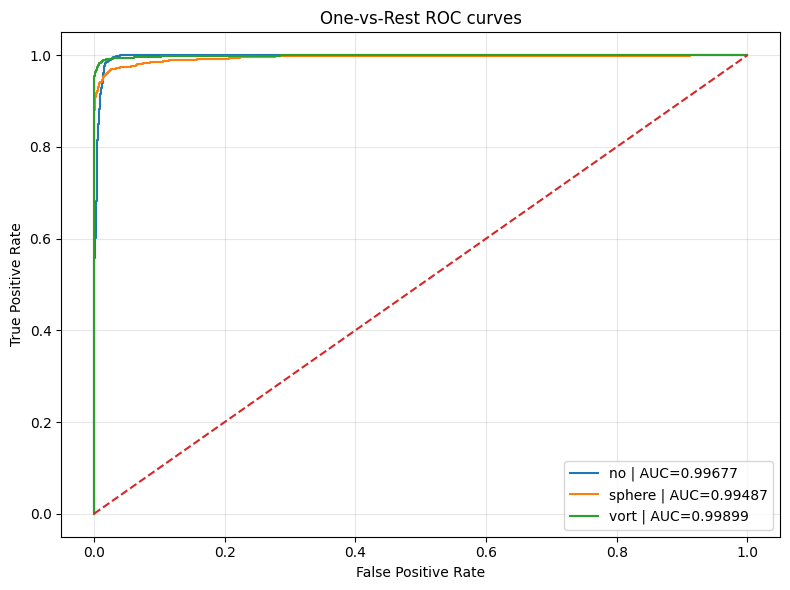

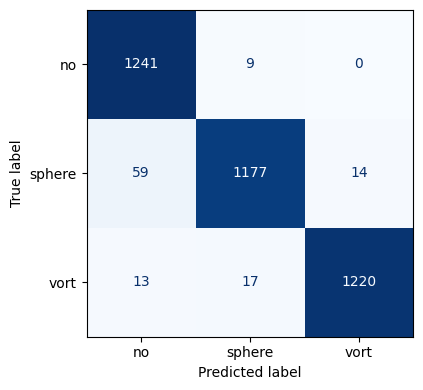

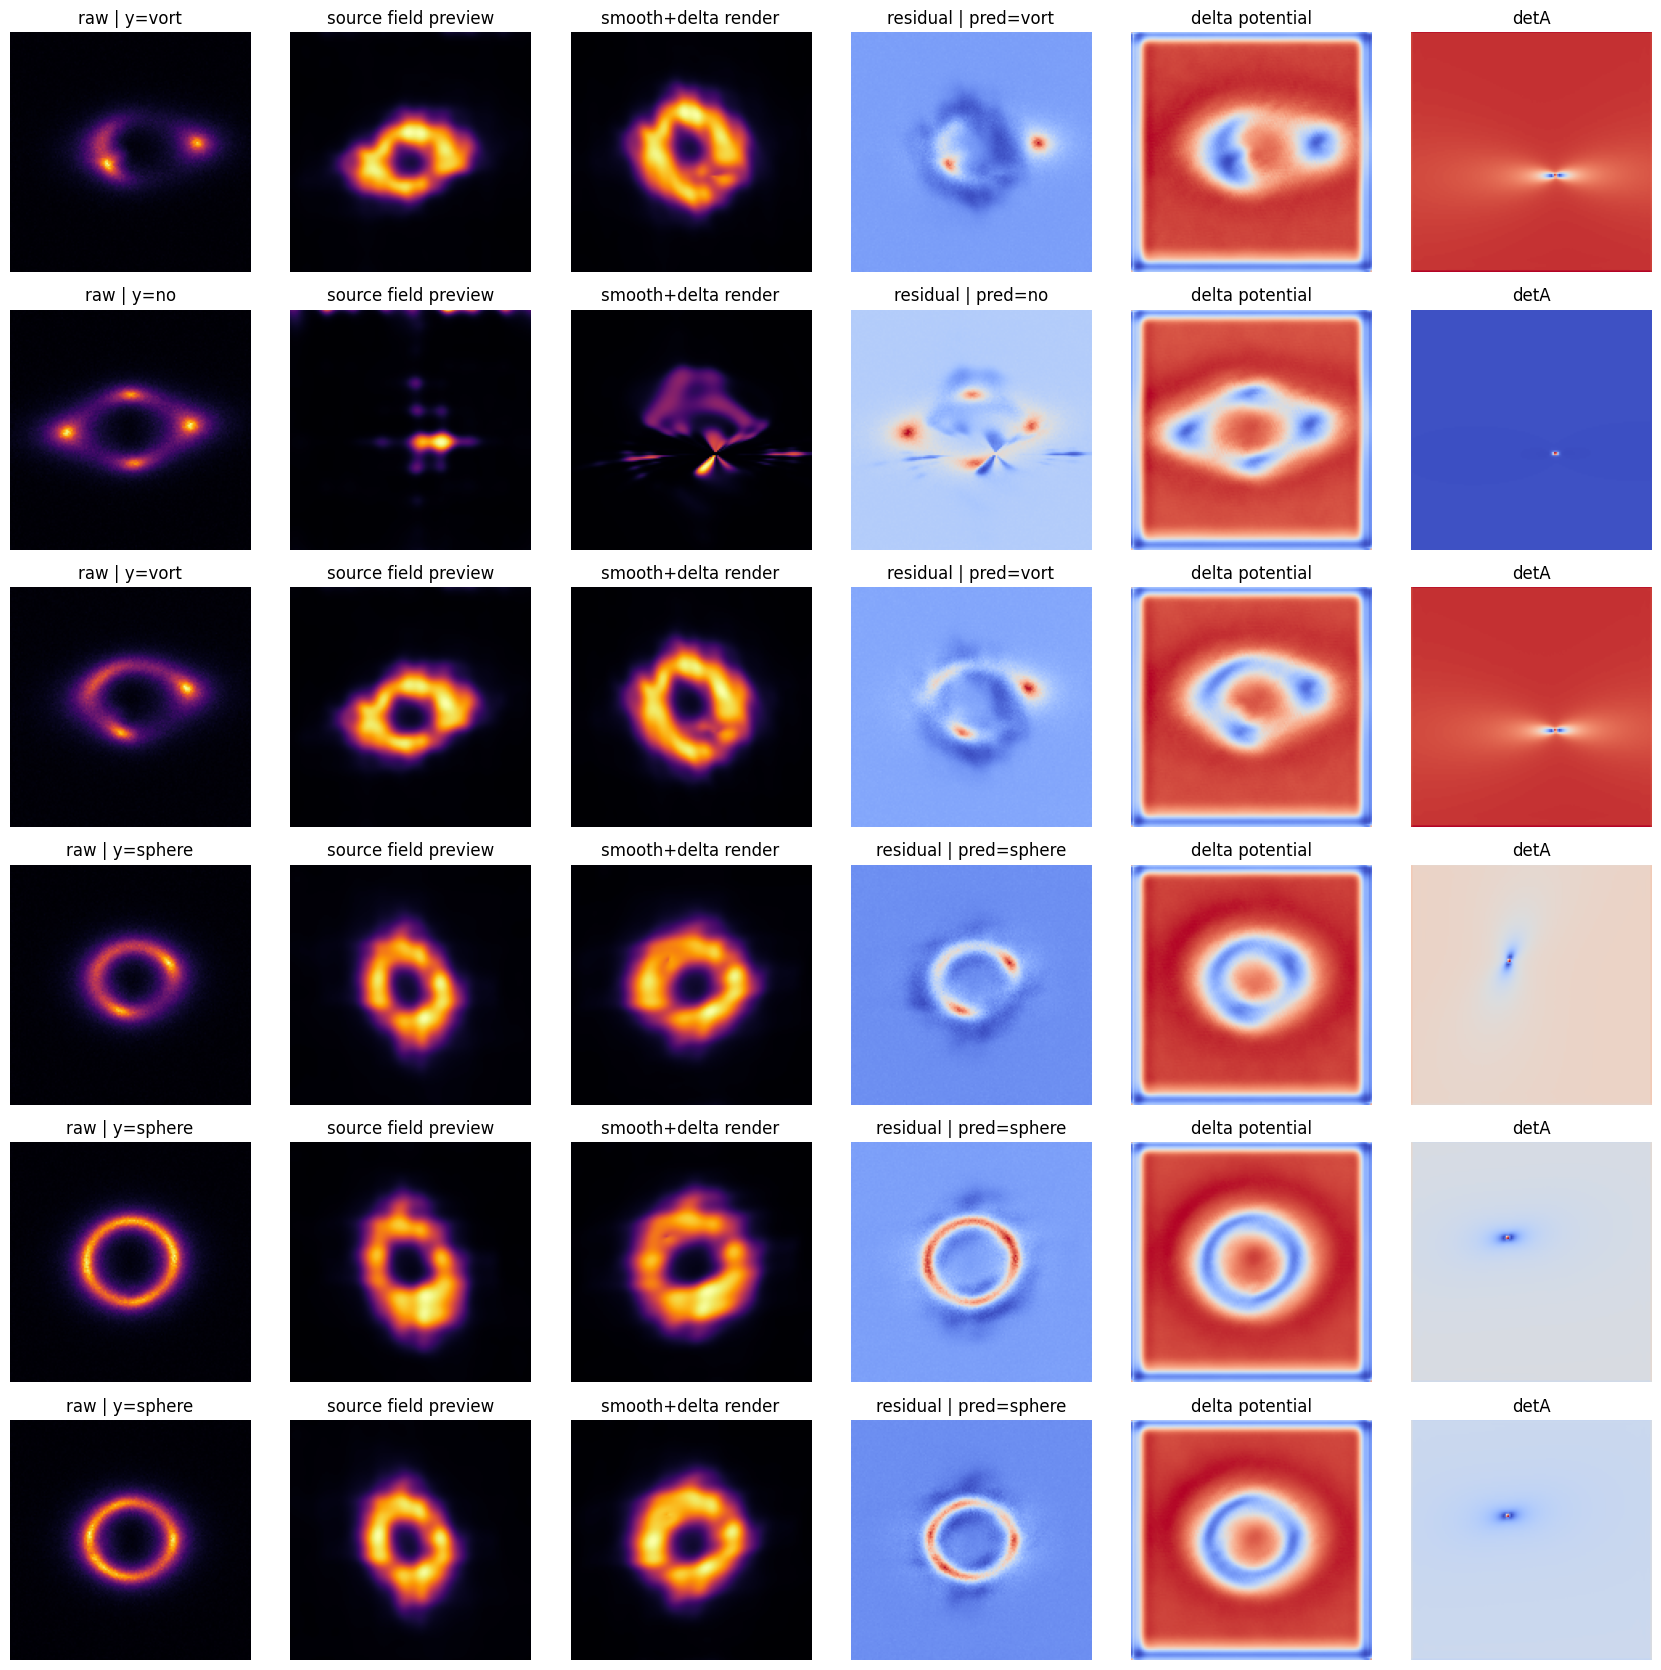

In [18]:

# Final evaluation after training
best_ckpt_path = Path(cfg.output_dir) / f"best_{cfg.model_name}_task7_residual_pinn.pth"
topk_csv_path = Path(cfg.output_dir) / "topk_checkpoints.csv"

best_model, best_bundle = load_checkpoint_model(best_ckpt_path)
ce_criterion = nn.CrossEntropyLoss()

# 1) single best checkpoint, no TTA
val_loss_plain, y_true_plain, y_prob_plain, metrics_plain, per_class_auc_plain = evaluate_model(
    best_model,
    val_loader,
    criterion=ce_criterion,
    use_d4_tta=False,
)
print(
    f"{cfg.model_name} residual-PINN | epoch {int(best_bundle['best_epoch'])}: "
    f"train_loss=see history_df | val_loss={val_loss_plain:.4f} | "
    f"val_acc={metrics_plain['accuracy']:.4f} | "
    f"val_macro_f1={metrics_plain['macro_f1']:.4f} | "
    f"val_macro_auc={metrics_plain['macro_auc_ovr']:.4f}"
)
print("per-class AUC:", per_class_auc_plain)

# 2) single best checkpoint, D4 TTA
_, y_true_tta, y_prob_tta, metrics_tta, per_class_auc_tta = evaluate_model(
    best_model,
    val_loader,
    criterion=None,
    use_d4_tta=cfg.use_d4_tta,
)

# 3) top-k checkpoint ensemble with D4 TTA
if topk_csv_path.exists():
    topk_df = pd.read_csv(topk_csv_path)
    ckpt_paths = topk_df.sort_values("macro_auc_ovr", ascending=False)["checkpoint_path"].tolist()[: cfg.final_eval_top_k]
else:
    ckpt_paths = [str(best_ckpt_path)]

y_true_ens, y_prob_ens = ensemble_predict_proba(ckpt_paths, val_loader, use_d4_tta=cfg.use_d4_tta)
metrics_ens, per_class_auc_ens = compute_auc_metrics(y_true_ens, y_prob_ens, cfg.class_names)

summary_rows = [
    {"setting": "best_ckpt_no_tta", **metrics_plain},
    {"setting": "best_ckpt_d4_tta", **metrics_tta},
    {"setting": f"top{len(ckpt_paths)}_ckpt_d4_tta_ensemble", **metrics_ens},
]
summary_df = pd.DataFrame(summary_rows).sort_values("macro_auc_ovr", ascending=False).reset_index(drop=True)
display(summary_df)

best_setting = summary_df.iloc[0]["setting"]
if best_setting == "best_ckpt_no_tta":
    final_y_true, final_y_prob = y_true_plain, y_prob_plain
elif best_setting == "best_ckpt_d4_tta":
    final_y_true, final_y_prob = y_true_tta, y_prob_tta
else:
    final_y_true, final_y_prob = y_true_ens, y_prob_ens

final_metrics, final_per_class_auc, final_y_pred = summarize_predictions(best_setting, final_y_true, final_y_prob)

final_payload = {
    "model_name": cfg.model_name,
    "best_epoch": int(best_bundle["best_epoch"]),
    "selected_setting": best_setting,
    "summary_table": summary_df.to_dict(orient="records"),
    "final_metrics": final_metrics,
    "final_per_class_auc": final_per_class_auc,
    "checkpoint_paths_used": ckpt_paths,
}
with open(Path(cfg.output_dir) / "final_metrics.json", "w") as f:
    json.dump(final_payload, f, indent=2)

pred_df = pd.DataFrame({
    "path": val_df["path"],
    "true_label": final_y_true,
    "pred_label": final_y_pred,
    "prob_no": final_y_prob[:, 0],
    "prob_sphere": final_y_prob[:, 1],
    "prob_vort": final_y_prob[:, 2],
})
pred_df.to_csv(Path(cfg.output_dir) / "val_predictions.csv", index=False)

visualize_physics_predictions(best_model, val_ds, n_samples=6)

del best_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## Practical strategy notes

This notebook is the **right place** to do Task VII work because the final model remains physics-guided:

- DenseNet still provides strong discriminative features
- the thin-lens equation is inside the forward pass
- the model predicts a smooth lens and a residual potential correction
- classification is driven by physically meaningful residual maps

High-impact things to tune next:

1. `lowpass_recon_weight`
2. `delta_psi_max`
3. `delta_psi_lap_weight`
4. `source_latent_dim` / `source_hidden_dim`
5. `batch_size`
6. whether the best final result comes from:
   - single best checkpoint
   - single best + D4 TTA
   - top-k checkpoint ensemble + D4 TTA

Most likely class to watch:
- **`sphere`**  
If a change improves `sphere` recall / AUC without hurting `vort`, it is usually worth keeping.

Important:
- this notebook is designed to give you a **stronger Task VII architecture**
- it is **not a guarantee** that every hyperparameter setting will beat your current best run
- treat it as a high-upside starting point and keep the old notebook/checkpoint as the regression-safe fallback
